In [1]:
import sys
!{sys.executable} -m pip install seaborn

In [2]:
import seaborn as sns
print("Seaborn installed successfully!")

Seaborn installed successfully!


In [3]:
import sys
print(sys.executable)

c:\Users\Renuka\AppData\Local\Programs\Python\Python311\python.exe


In [4]:
!python -m pip install ipykernel

In [5]:
!python -m ipykernel install --user --name python311 --display-name "Python 3.11"

Installed kernelspec python311 in C:\Users\Renuka\AppData\Roaming\jupyter\kernels\python311


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

import numpy as np
import matplotlib.pyplot as plt

# Install seaborn if not installed
try:
    import seaborn as sns
except:
    !pip install seaborn
    import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [8]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "C:/Users/Renuka/OneDrive/Desktop/capstone phase2/processed_image/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    "C:/Users/Renuka/OneDrive/Desktop/capstone phase2/processed_image/valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    "C:/Users/Renuka/OneDrive/Desktop/capstone phase2/processed_image/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_data.class_names
print(class_names)

Found 3022 files belonging to 6 classes.
Found 860 files belonging to 6 classes.
Found 433 files belonging to 6 classes.
['Dermatitis', 'Fungal_infections', 'Healthy', 'Hypersensitivity', 'demodicosis', 'ringworm']


In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

In [10]:
base_model = ResNet50(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [11]:
model = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(6, activation='softmax')
])

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.6267 - loss: 1.1514 - val_accuracy: 0.6977 - val_loss: 0.8538
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.7340 - loss: 0.7905 - val_accuracy: 0.7453 - val_loss: 0.7390
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 251s 3s/step - accuracy: 0.7770 - loss: 0.6408 - val_accuracy: 0.7733 - val_loss: 0.6514
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.8111 - loss: 0.5520 - val_accuracy: 0.8372 - val_loss: 0.4766
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.8266 - loss: 0.4935 - val_accuracy: 0.8442 - val_loss: 0.5165
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.8422 - loss: 0.4660 - val_accuracy: 0.8384 - val_loss: 0.4819
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.8511 - loss: 0.4051 - val_accuracy: 0.8500 - val_loss: 0.4885
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.8650 - loss: 0.3809 - val_accuracy: 0.8512 - v

In [14]:
base_model = model.layers[1]
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.8448 - loss: 0.4249 - val_accuracy: 0.8628 - val_loss: 0.4539
Epoch 2/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.8733 - loss: 0.3394 - val_accuracy: 0.8640 - val_loss: 0.4328
Epoch 3/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.8706 - loss: 0.3481 - val_accuracy: 0.8767 - val_loss: 0.4107
Epoch 4/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.8938 - loss: 0.2908 - val_accuracy: 0.8860 - val_loss: 0.3962
Epoch 5/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 393s 4s/step - accuracy: 0.9004 - loss: 0.2814 - val_accuracy: 0.8837 - val_loss: 0.3802


In [17]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 755ms/step - accuracy: 0.9122 - loss: 0.2779
Test Accuracy: 0.912240207195282


In [18]:
y_true = []
y_pred = []

for images, labels in test_data:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 776ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 799ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 789ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 815ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


In [19]:
print(classification_report(y_true, y_pred, target_names=class_names))

                   precision    recall  f1-score   support

       Dermatitis       0.93      0.83      0.88        66
Fungal_infections       0.81      0.87      0.84        54
          Healthy       0.92      0.96      0.94        69
 Hypersensitivity       0.83      0.86      0.85        29
      demodicosis       0.97      0.94      0.95       100
         ringworm       0.92      0.94      0.93       115

         accuracy                           0.91       433
        macro avg       0.90      0.90      0.90       433
     weighted avg       0.91      0.91      0.91       433



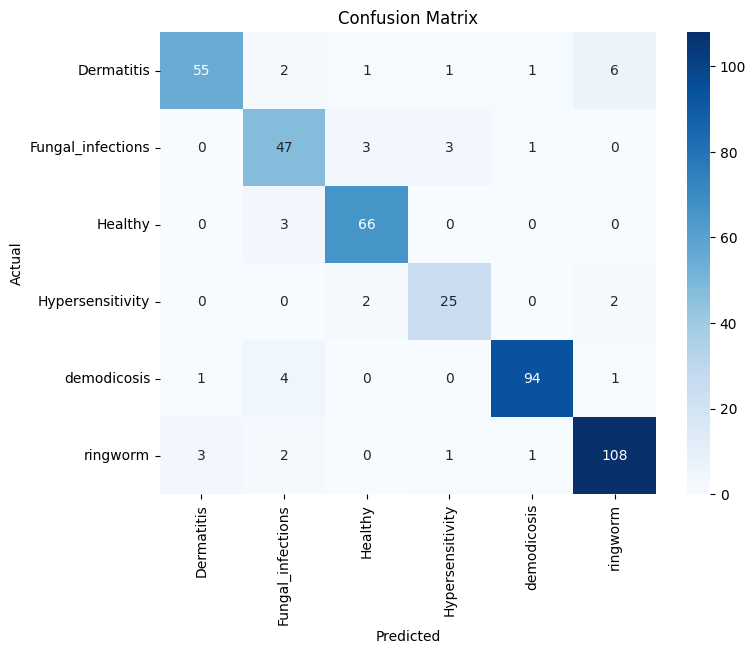

In [20]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [21]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[checkpoint]
)

Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 259s 3s/step - accuracy: 0.9136 - loss: 0.2420 - val_accuracy: 0.8872 - val_loss: 0.3742
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 285s 3s/step - accuracy: 0.9133 - loss: 0.2481 - val_accuracy: 0.8907 - val_loss: 0.3657
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 412s 4s/step - accuracy: 0.9163 - loss: 0.2400 - val_accuracy: 0.8919 - val_loss: 0.3632
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 352s 4s/step - accuracy: 0.9289 - loss: 0.2029 - val_accuracy: 0.8919 - val_loss: 0.3612
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.9289 - loss: 0.2025 - val_accuracy: 0.9012 - val_loss: 0.3519
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 752s 8s/step - accuracy: 0.9381 - loss: 0.1786 - val_accuracy: 0.9023 - val_loss: 0.3426
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.9361 - loss: 0.1832 - val_accuracy: 0.9035 - val_loss: 0.3311
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.9411 - loss: 0.1821 - val_accuracy: 0.9058 - v

In [22]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 865ms/step - accuracy: 0.9376 - loss: 0.2173
Test Accuracy: 0.937644362449646


In [23]:
y_true = []
y_pred = []

for images, labels in test_data:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 940ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 957ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 952ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 954ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 948ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 954ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 964ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 980ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 959ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 609ms/step


In [24]:
print(classification_report(y_true, y_pred, target_names=class_names))

                   precision    recall  f1-score   support

       Dermatitis       0.92      0.89      0.91        66
Fungal_infections       0.90      0.87      0.89        54
          Healthy       0.92      0.96      0.94        69
 Hypersensitivity       0.87      0.90      0.88        29
      demodicosis       0.99      0.98      0.98       100
         ringworm       0.95      0.96      0.95       115

         accuracy                           0.94       433
        macro avg       0.92      0.93      0.92       433
     weighted avg       0.94      0.94      0.94       433



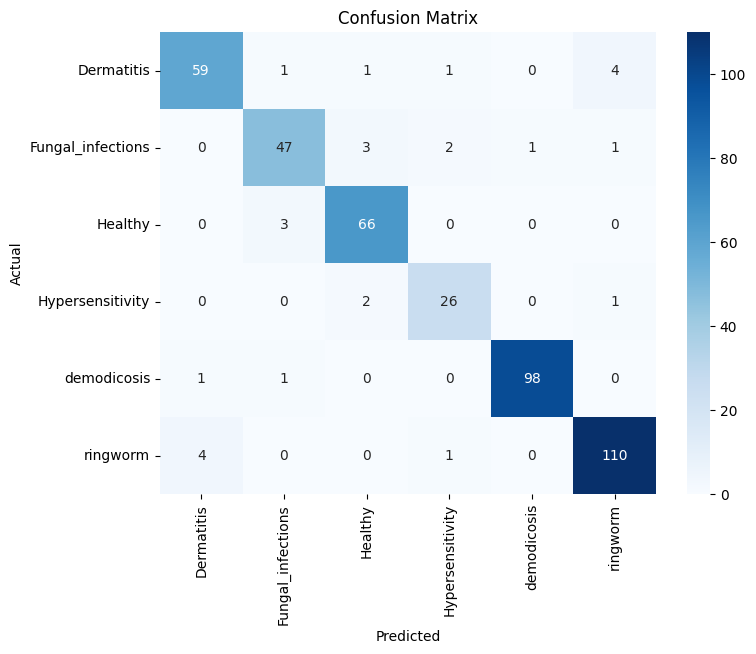

In [25]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()